In [203]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Dataset: Read

In [204]:
FILE_ID = "1PPp0KKJ7wBMex3loW0dAruk_6cBaztPY"

url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1529, 22)


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


# Dataset Overview

In [205]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nTarget distributions:")
display(df["CVD Risk Level"].value_counts())

Rows: 1529
Columns: 22

Data types:


,dtype
Sex,object
Age,float64
Weight (kg),float64
Height (m),float64
BMI,float64
Abdominal Circumference (cm),float64
Blood Pressure (mmHg),object
Total Cholesterol (mg/dL),float64
HDL (mg/dL),float64
Fasting Blood Sugar (mg/dL),float64



Duplicate rows: 0

Missing values:


,missing_count
Diastolic BP,82
Weight (kg),81
HDL (mg/dL),80
Waist-to-Height Ratio,79
Age,78
Height (cm),74
Total Cholesterol (mg/dL),73
Systolic BP,71
CVD Risk Score,70
Estimated LDL (mg/dL),69



Target distributions:


,count
CVD Risk Level,
HIGH,728
INTERMEDIARY,581
LOW,220


# Data Cleaning & Feature Recovery

In [206]:
data = df.copy()

# Recover systolic/diastolic BP from the complete BP string where needed.
bp_parts = data["Blood Pressure (mmHg)"].str.extract(r"(?P<bp_sys>\d+(?:\.\d+)?)/(?P<bp_dia>\d+(?:\.\d+)?)")
bp_sys = pd.to_numeric(bp_parts["bp_sys"], errors="coerce")
bp_dia = pd.to_numeric(bp_parts["bp_dia"], errors="coerce")

data["Systolic BP"] = data["Systolic BP"].fillna(bp_sys)
data["Diastolic BP"] = data["Diastolic BP"].fillna(bp_dia)

# Recover height in meters from height in centimeters where possible.
data["Height (m)"] = data["Height (m)"].fillna(data["Height (cm)"] / 100)

# Invalid negative LDL is not physiologically meaningful.
data.loc[data["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan

# Recalculate BMI only when missing and the required measurements exist.
bmi_calc = data["Weight (kg)"] / (data["Height (m)"] ** 2)
data["BMI"] = data["BMI"].fillna(bmi_calc)

# Remove duplicate/target columns.
target_reg = "CVD Risk Score"
target_cls = "CVD Risk Level"

drop_cols = [
    target_reg,
    target_cls,
    "Blood Pressure (mmHg)",
    "Height (cm)"
]

X = data.drop(columns=drop_cols)
y_reg = data[target_reg]
y_cls = data[target_cls]

print("Features used:", X.columns.tolist())
print("\nRemaining missing values in features:")
display(X.isnull().sum().sort_values(ascending=False).to_frame("missing"))

Features used: ['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)']

Remaining missing values in features:


,missing
Estimated LDL (mg/dL),82
Weight (kg),81
HDL (mg/dL),80
Waist-to-Height Ratio,79
Age,78
Total Cholesterol (mg/dL),73
Fasting Blood Sugar (mg/dL),67
Abdominal Circumference (cm),67
Height (m),6
BMI,5


# EDA (Numerical Features)

,count,mean,std,min,25%,50%,75%,max
Age,1451.0,47.025500,12.421063,25.00,37.000,46.0000,55.00000,79.000
Weight (kg),1448.0,85.917427,21.012580,50.10,67.050,86.6145,105.00000,120.000
Height (m),1523.0,1.753834,0.112701,1.50,1.660,1.7570,1.84200,2.000
BMI,1524.0,28.417471,7.033652,15.00,22.600,28.1445,33.90000,46.200
Abdominal Circumference (cm),1462.0,91.773214,12.823573,70.00,80.500,91.6000,102.26900,119.996
Total Cholesterol (mg/dL),1456.0,198.539148,57.794099,100.00,150.000,197.0000,249.00000,300.000
HDL (mg/dL),1449.0,56.197378,16.066754,30.00,42.000,56.0000,70.00000,89.000
Fasting Blood Sugar (mg/dL),1462.0,117.485636,30.289174,70.00,92.000,115.0000,138.00000,198.000
Height (cm),1455.0,175.390600,11.251527,150.00,166.000,175.6940,184.20850,199.960
Waist-to-Height Ratio,1450.0,0.525727,0.081213,0.36,0.460,0.5220,0.58375,0.787


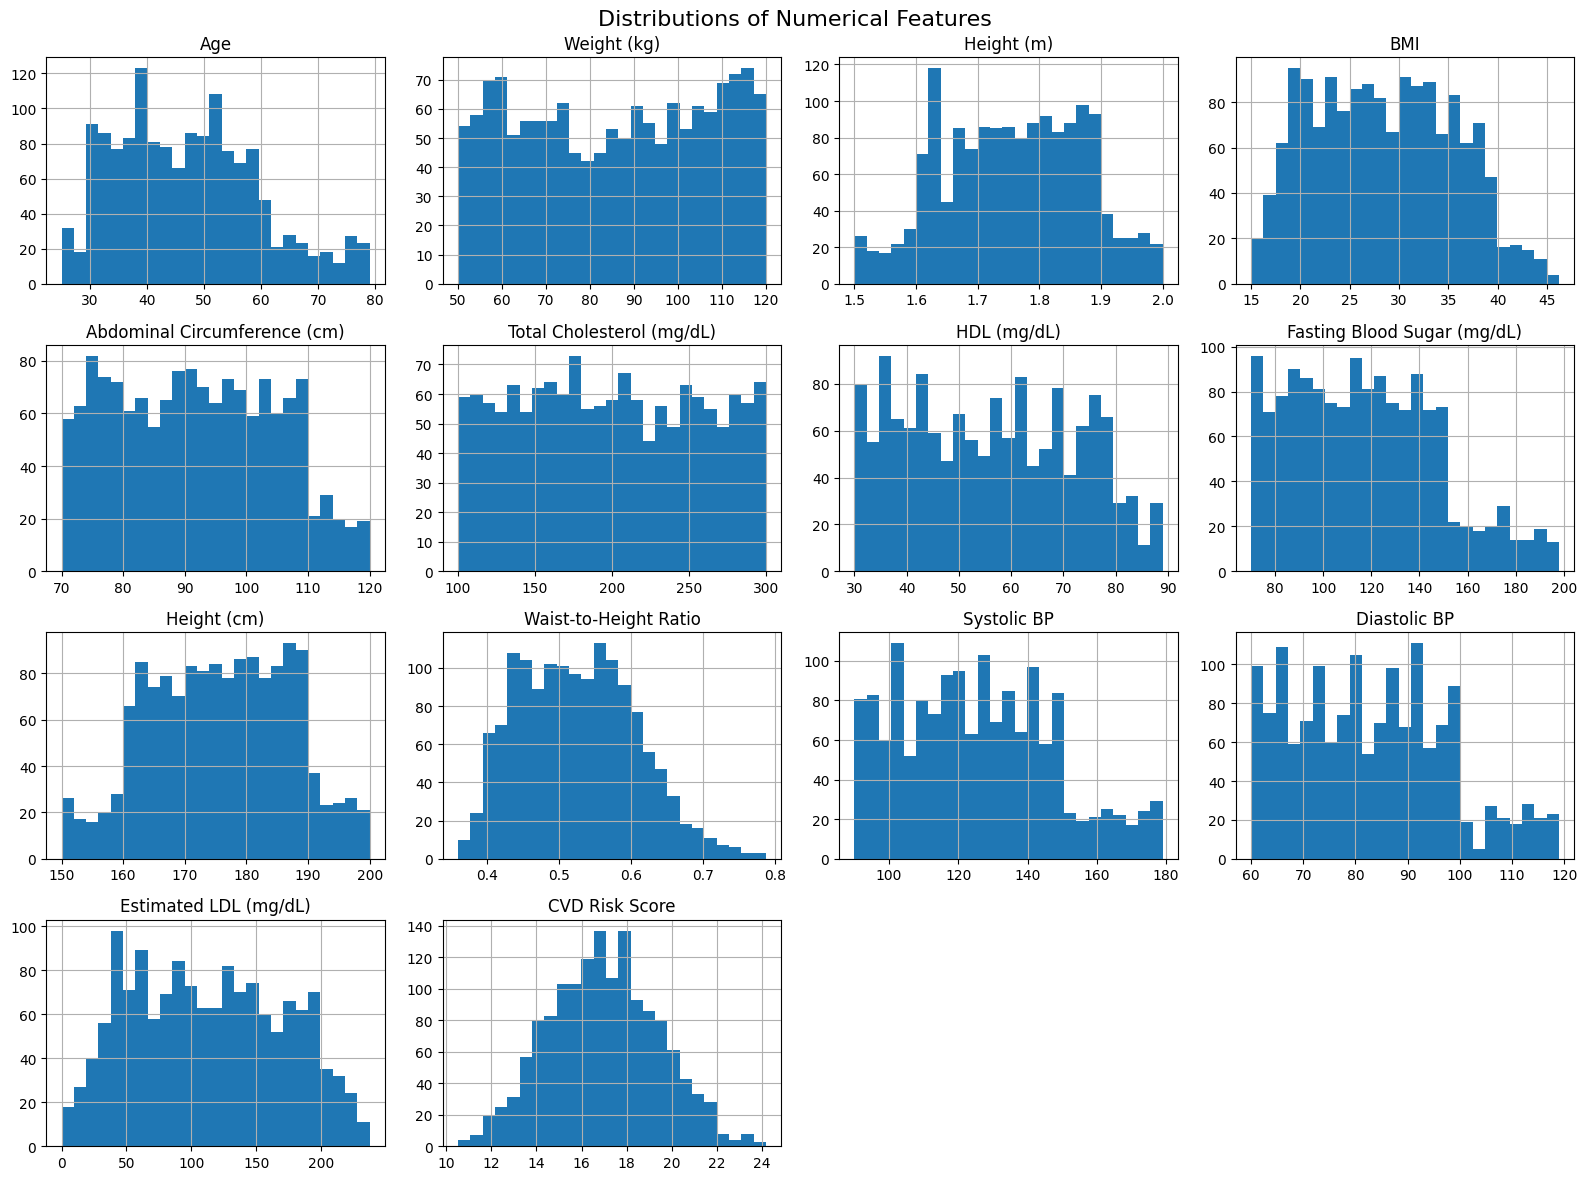

In [207]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
display(data[numeric_cols].describe().T)

# Histograms
data[numeric_cols].hist(figsize=(16, 12), bins=25)
plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# EDA (Categorical Features and Targets)

,count
Sex,
F,773
M,756


,count
Blood Pressure (mmHg),
113/77,4
114/63,4
127/84,4
113/79,4
148/98,3
...,...
120/97,1
93/73,1
96/71,1


,count
Smoking Status,
Y,789
N,740


,count
Diabetes Status,
Y,777
N,752


,count
Physical Activity Level,
High,521
Moderate,512
Low,496


,count
Family History of CVD,
N,780
Y,749


,count
Blood Pressure Category,
Hypertension Stage 2,632
Hypertension Stage 1,497
Normal,300
Elevated,100


,count
CVD Risk Level,
HIGH,728
INTERMEDIARY,581
LOW,220


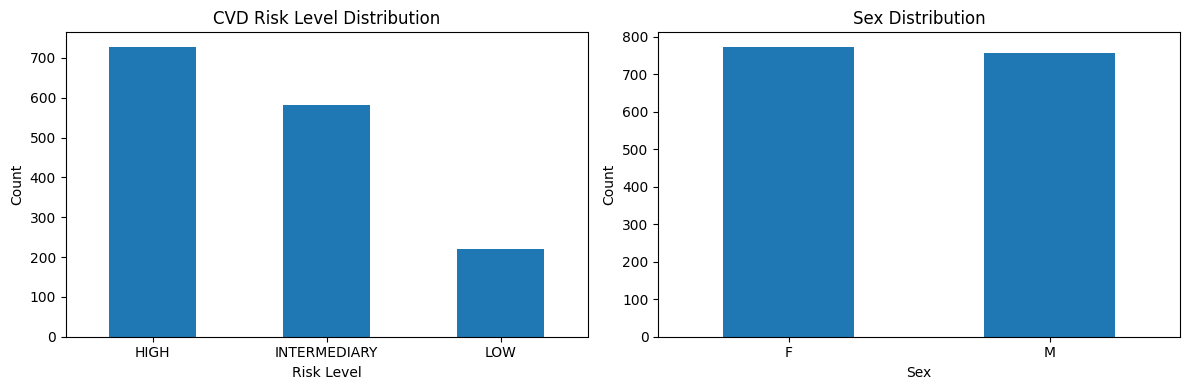

In [208]:
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

for col in categorical_cols:
    display(data[col].value_counts(dropna=False).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["CVD Risk Level"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("CVD Risk Level Distribution")
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

data["Sex"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex Distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# EDA Correlation with the Numerical Target

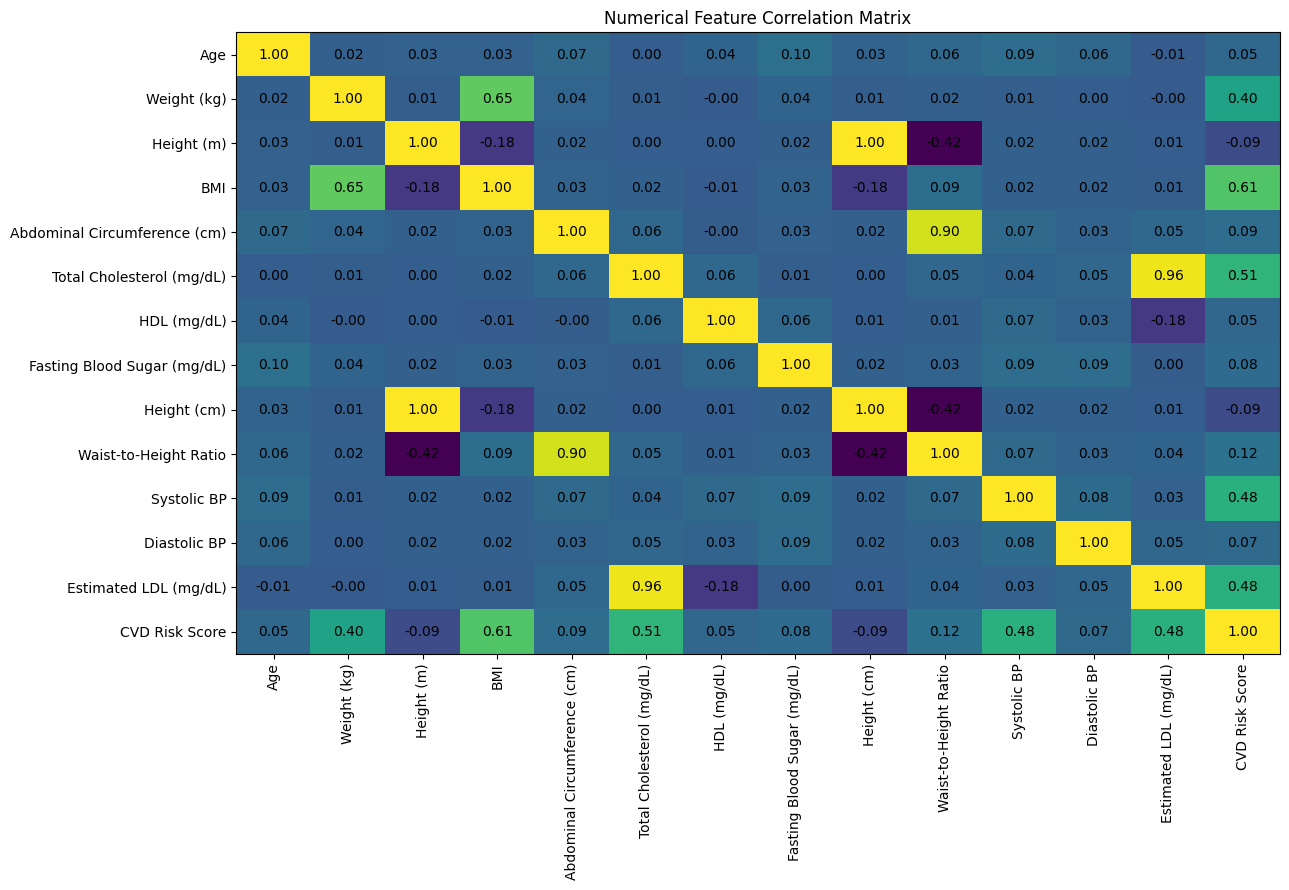

In [209]:
corr = data[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 9))
plt.imshow(corr, aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

# Add correlation values [each cell]
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Training Testing

In [210]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (1223, 18)
Testing set shape : (306, 18)

Training target distribution:
CVD Risk Level
HIGH            582
INTERMEDIARY    465
LOW             176
Name: count, dtype: int64

Testing target distribution:
CVD Risk Level
HIGH            146
INTERMEDIARY    116
LOW              44
Name: count, dtype: int64


In [211]:

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']

Categorical features:
['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


In [212]:


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic Regression

In [213]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY'
 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'HIGH'
 'INTERMEDIARY']


In [214]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6535947712418301

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.71      0.75      0.73       146
INTERMEDIARY       0.63      0.74      0.68       116
         LOW       0.31      0.09      0.14        44

    accuracy                           0.65       306
   macro avg       0.55      0.53      0.52       306
weighted avg       0.62      0.65      0.63       306



# Random Forest

In [215]:
import numpy as np

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same preprocessor
X_test_processed = preprocessor.transform(X_test)

# Convert to NumPy arrays
if hasattr(X_train_processed, "toarray"):
    X_train_np = X_train_processed.toarray()
else:
    X_train_np = np.asarray(X_train_processed)

if hasattr(X_test_processed, "toarray"):
    X_test_np = X_test_processed.toarray()
else:
    X_test_np = np.asarray(X_test_processed)

y_train_np = np.asarray(y_train)
y_test_np = np.asarray(y_test)

print("Training shape:", X_train_np.shape)
print("Testing shape :", X_test_np.shape)

Training shape: (1223, 27)
Testing shape : (306, 27)


In [216]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier


class RandomForest:
    def __init__(
        self,
        n_estimators=100,
        max_depth=None,
        random_state=42
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state

        # Store all Decision Trees
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_samples = X.shape[0]

        random_generator = np.random.default_rng(
            self.random_state
        )

        self.trees = []

        # Create the requested number of trees
        for tree_number in range(self.n_estimators):
            sample_indices = random_generator.choice(
                n_samples,
                size=n_samples,
                replace=True
            )

            # Create bootstrap training sample
            X_sample = X[sample_indices]
            y_sample = y[sample_indices]

            # Create one Decision Tree
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                max_features="sqrt",

                random_state=(
                    self.random_state + tree_number
                )
            )

            # Train the tree
            tree.fit(
                X_sample,
                y_sample
            )

            # Store trained tree
            self.trees.append(tree)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        if len(self.trees) == 0:
            raise ValueError(
                "The Random Forest has not been trained."
            )

        # Collect predictions
        all_predictions = np.array([
            tree.predict(X)
            for tree in self.trees
        ])

        final_predictions = []

        # Majority voting
        for sample_predictions in all_predictions.T:

            classes, counts = np.unique(
                sample_predictions,
                return_counts=True
            )

            majority_class = classes[
                np.argmax(counts)
            ]

            final_predictions.append(
                majority_class
            )
        return np.asarray(final_predictions)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)

        if len(self.trees) == 0:
            raise ValueError(
                "The Random Forest has not been trained."
            )

        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        proba_sum = np.zeros((n_samples, n_classes))

        for tree in self.trees:
            tree_proba = tree.predict_proba(X)
            for class_index, class_label in enumerate(self.classes_):
                if class_label in tree.classes_:
                    tree_col = list(tree.classes_).index(class_label)
                    proba_sum[:, class_index] += tree_proba[:, tree_col]

        return proba_sum / len(self.trees)

In [217]:
# Create the Random Forest object
random_forest = RandomForest(
    n_estimators=25,
    max_depth=5,
    random_state=42
)

# Train it using the existing training data
random_forest.fit(
    X_train_np,
    y_train_np
)

print("Random Forest training completed.")
print("Number of trees:", len(random_forest.trees))

y_pred_rf_scr = random_forest.predict(
    X_test_np
)

print("First 20 predictions:")
print(y_pred_rf_scr[:20])

Random Forest training completed.
Number of trees: 25
First 20 predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY'
 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'HIGH' 'HIGH' 'HIGH' 'HIGH'
 'INTERMEDIARY' 'INTERMEDIARY']


In [218]:
from sklearn.metrics import accuracy_score

accuracy_rf_scr = accuracy_score(
    y_test_np,
    y_pred_rf_scr
)

print(
    "Random Forest Classifier Accuracy:",
    accuracy_rf_scr
)

Random Forest Classifier Accuracy: 0.5882352941176471


In [219]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test_np,
        y_pred_rf_scr
    )
)

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.61      0.74      0.67       146
INTERMEDIARY       0.56      0.62      0.59       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.59       306
   macro avg       0.39      0.45      0.42       306
weighted avg       0.50      0.59      0.54       306



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Adaboost Classifier

In [220]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [221]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier


class AdaBoostClassifierScratch:
    def __init__(
        self,
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state

        self.models = []
        self.alphas = []
        self.classes_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)

        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        # Initially, all samples have equal weights
        weights = np.ones(n_samples) / n_samples

        self.models = []
        self.alphas = []

        for estimator in range(self.n_estimators):

            # Create a Decision Stump
            stump = DecisionTreeClassifier(
                max_depth=1,
                random_state=self.random_state + estimator
            )
            stump.fit(
                X,
                y,
                sample_weight=weights
            )

            # Predict
            predictions = stump.predict(X)
            incorrect = predictions != y
            error = np.sum(
                weights * incorrect
            )

            error = np.clip(
                error,
                1e-10,
                1 - 1e-10
            )
            maximum_error = 1 - (1 / n_classes)

            if error >= maximum_error:
                break

            # SAMME amount-of-say formula
            alpha = self.learning_rate * (
                np.log((1 - error) / error)
                + np.log(n_classes - 1)
            )

            self.models.append(stump)
            self.alphas.append(alpha)

            # Increase weights of incorrect samples
            weights *= np.exp(
                alpha * incorrect
            )

            # Normalize weights
            weights /= np.sum(weights)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        if len(self.models) == 0:
            raise ValueError(
                "AdaBoost did not train any valid stumps."
            )

        # Score for each class
        class_scores = np.zeros(
            (X.shape[0], len(self.classes_))
        )

        for alpha, stump in zip(
            self.alphas,
            self.models
        ):
            predictions = stump.predict(X)

            for class_index, class_label in enumerate(
                self.classes_
            ):
                class_scores[:, class_index] += (
                    alpha
                    * (predictions == class_label)
                )

        best_class_indices = np.argmax(
            class_scores,
            axis=1
        )
        return self.classes_[best_class_indices]

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)

        if len(self.models) == 0:
            raise ValueError(
                "AdaBoost did not train any valid stumps."
            )

        class_scores = np.zeros(
            (X.shape[0], len(self.classes_))
        )

        for alpha, stump in zip(self.alphas, self.models):
            predictions = stump.predict(X)

            for class_index, class_label in enumerate(self.classes_):
                class_scores[:, class_index] += (
                    alpha * (predictions == class_label)
                )

        # Convert weighted votes into probabilities via softmax
        exp_scores = np.exp(class_scores - class_scores.max(axis=1, keepdims=True))
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

In [222]:
adaboost = AdaBoostClassifierScratch(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

adaboost.fit(
    X_train_np,
    y_train_np
)

print("AdaBoost training completed.")
print("Trained stumps:", len(adaboost.models))

y_pred_ab = adaboost.predict(
    X_test_np
)

print("First 20 predictions:")
print(y_pred_ab[:20])

AdaBoost training completed.
Trained stumps: 50
First 20 predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'HIGH'
 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'HIGH' 'HIGH' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'INTERMEDIARY']


In [223]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy_ab = accuracy_score(
    y_test_np,
    y_pred_ab
)
print("AdaBoost Accuracy:", accuracy_ab)
print("\nClassification Report:")
print(
    classification_report(
        y_test_np,
        y_pred_ab
    )
)

AdaBoost Accuracy: 0.6437908496732027

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.66      0.77      0.71       146
INTERMEDIARY       0.63      0.73      0.68       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.64       306
   macro avg       0.43      0.50      0.46       306
weighted avg       0.56      0.64      0.60       306



In [224]:
from sklearn.model_selection import train_test_split

X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train,
    y_train,
    train_size=0.875,  # 70/80 = 0.875
    random_state=42,
    stratify=y_train
)

print("Training shape  :", X_nn_train.shape)
print("Validation shape:", X_nn_val.shape)
print("Testing shape   :", X_test.shape)

Training shape  : (1070, 18)
Validation shape: (153, 18)
Testing shape   : (306, 18)


# Neural Networks

In [225]:
import numpy as np
from sklearn.base import clone

nn_preprocessor = clone(preprocessor)

# Fit only on the 70% training data
X_nn_train_np = nn_preprocessor.fit_transform(
    X_nn_train
)

X_nn_val_np = nn_preprocessor.transform(
    X_nn_val
)

X_nn_test_np = nn_preprocessor.transform(
    X_test
)

# Convert sparse matrices to arrays
if hasattr(X_nn_train_np, "toarray"):
    X_nn_train_np = X_nn_train_np.toarray()
    X_nn_val_np = X_nn_val_np.toarray()
    X_nn_test_np = X_nn_test_np.toarray()

print("Processed training shape  :", X_nn_train_np.shape)
print("Processed validation shape:", X_nn_val_np.shape)
print("Processed testing shape   :", X_nn_test_np.shape)

Processed training shape  : (1070, 27)
Processed validation shape: (153, 27)
Processed testing shape   : (306, 27)


In [226]:
from sklearn.preprocessing import LabelEncoder

label_encoder_nn = LabelEncoder()

y_nn_train_encoded = label_encoder_nn.fit_transform(
    y_nn_train
)

y_nn_val_encoded = label_encoder_nn.transform(
    y_nn_val
)

y_nn_test_encoded = label_encoder_nn.transform(
    y_test
)

print("Classes:", label_encoder_nn.classes_)

Classes: ['HIGH' 'INTERMEDIARY' 'LOW']


In [227]:
import tensorflow as tf

tf.random.set_seed(42)

neural_network = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_nn_train_np.shape[1],)
    ),

    # Hidden layer 1
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    # Hidden layer 2
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    # Hidden layer 3
    tf.keras.layers.Dense(16, activation="relu"),

    # Output layer
    tf.keras.layers.Dense(3, activation="softmax")
])

neural_network.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

neural_network.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,451 (17.39 KB)

 Trainable params: 4,451 (17.39 KB)

 Non-trainable params: 0 (0.00 B)

In [228]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = neural_network.fit(
    X_nn_train_np,
    y_nn_train_encoded,

    validation_data=(
        X_nn_val_np,
        y_nn_val_encoded
    ),

    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4252 - loss: 1.0467 - val_accuracy: 0.5098 - val_loss: 0.9907
Epoch 2/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4916 - loss: 0.9941 - val_accuracy: 0.5098 - val_loss: 0.9622
Epoch 3/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5215 - loss: 0.9492 - val_accuracy: 0.5490 - val_loss: 0.9219
Epoch 4/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5804 - loss: 0.9135 - val_accuracy: 0.5686 - val_loss: 0.8847
Epoch 5/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5832 - loss: 0.8852 - val_accuracy: 0.6144 - val_loss: 0.8498
Epoch 6/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6159 - loss: 0.8536 - val_accuracy: 0.6144 - val_loss: 0.8278
Epoch 7/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6299 - loss: 0.8420 - val_accuracy: 0.6536 - val_loss: 0.8091
Epoch 8/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6299 - loss: 0.8209 - val_accuracy: 0.6275 - 

In [229]:
test_loss, test_accuracy = neural_network.evaluate(
    X_nn_test_np,
    y_nn_test_encoded,
    verbose=0
)

print("Neural Network Test Accuracy:", test_accuracy)

Neural Network Test Accuracy: 0.6797385811805725


In [242]:
prediction_probabilities = neural_network.predict(
    X_nn_test_np
)

# Select the class with the highest probability
y_pred_nn_encoded = np.argmax(
    prediction_probabilities,
    axis=1
)

# Convert numbers back to original class names
y_pred_nn = label_encoder_nn.inverse_transform(
    y_pred_nn_encoded
)

print("First 20 predictions:")
print(y_pred_nn[:20])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
First 20 predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY'
 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'HIGH'
 'INTERMEDIARY']


In [243]:
from sklearn.metrics import (
    classification_report
)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_nn
    )
)

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.71      0.77      0.74       146
INTERMEDIARY       0.67      0.72      0.69       116
         LOW       0.52      0.25      0.34        44

    accuracy                           0.68       306
   macro avg       0.63      0.58      0.59       306
weighted avg       0.67      0.68      0.67       306



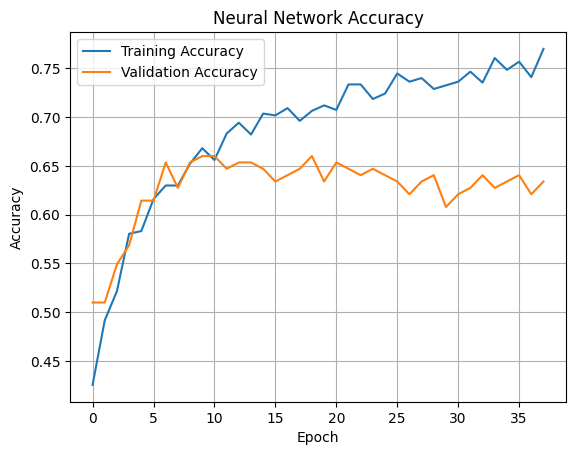

In [244]:
import matplotlib.pyplot as plt

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Accuracy")
plt.legend()
plt.grid()
plt.show()

# PCA for Dimensionality Reduction

In [245]:
from sklearn.decomposition import PCA
import numpy as np

n_numeric = len(numeric_features)  # count of numeric columns before one-hot

X_train_numeric = X_train_np[:, :n_numeric]
X_train_categorical = X_train_np[:, n_numeric:]

X_test_numeric = X_test_np[:, :n_numeric]
X_test_categorical = X_test_np[:, n_numeric:]

pca = PCA(n_components=0.95, random_state=42)

X_train_numeric_pca = pca.fit_transform(X_train_numeric)
X_test_numeric_pca = pca.transform(X_test_numeric)

# Recombine reduced numeric components with untouched categorical dummies
X_train_pca = np.hstack([X_train_numeric_pca, X_train_categorical])
X_test_pca = np.hstack([X_test_numeric_pca, X_test_categorical])

print("Original numeric feature count:", X_train_numeric.shape[1])
print("Components kept (95% variance):", pca.n_components_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())
print("Categorical (untouched) columns:", X_train_categorical.shape[1])
print("Final combined shape:", X_train_pca.shape)

Original numeric feature count: 12
Components kept (95% variance): 9
Total variance explained: 0.9624860159502157
Categorical (untouched) columns: 15
Final combined shape: (1223, 24)


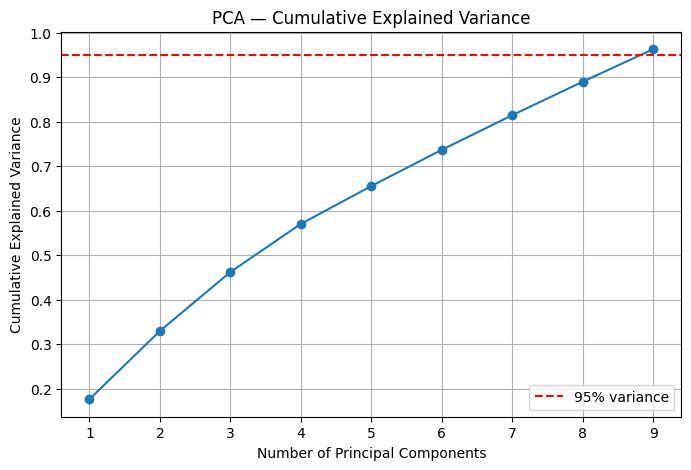

In [246]:
import matplotlib.pyplot as plt
import numpy as np

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

# Re-training the Existing Models on PCA Data

In [247]:
# Logistic Regression on PCA data
logistic_model_pca = LogisticRegression(max_iter=1000, random_state=42)
logistic_model_pca.fit(X_train_pca, y_train_np)

y_pred_lr_pca = logistic_model_pca.predict(X_test_pca)
accuracy_lr_pca = accuracy_score(y_test_np, y_pred_lr_pca)

print("Logistic Regression (PCA) Accuracy:", accuracy_lr_pca)

Logistic Regression (PCA) Accuracy: 0.6405228758169934


In [248]:
# Random Forest (scratch) on PCA data
random_forest_pca = RandomForest(n_estimators=25, max_depth=5, random_state=42)
random_forest_pca.fit(X_train_pca, y_train_np)

y_pred_rf_pca = random_forest_pca.predict(X_test_pca)
accuracy_rf_pca = accuracy_score(y_test_np, y_pred_rf_pca)

print("Random Forest (PCA) Accuracy:", accuracy_rf_pca)

Random Forest (PCA) Accuracy: 0.6241830065359477


In [249]:
# AdaBoost (scratch) on PCA data
adaboost_pca = AdaBoostClassifierScratch(n_estimators=50, learning_rate=1.0, random_state=42)
adaboost_pca.fit(X_train_pca, y_train_np)

y_pred_ab_pca = adaboost_pca.predict(X_test_pca)
accuracy_ab_pca = accuracy_score(y_test_np, y_pred_ab_pca)

print("AdaBoost (PCA) Accuracy:", accuracy_ab_pca)

AdaBoost (PCA) Accuracy: 0.5947712418300654


In [250]:
X_nn_train_numeric = X_nn_train_np[:, :n_numeric]
X_nn_train_categorical = X_nn_train_np[:, n_numeric:]

X_nn_val_numeric = X_nn_val_np[:, :n_numeric]
X_nn_val_categorical = X_nn_val_np[:, n_numeric:]

X_nn_test_numeric = X_nn_test_np[:, :n_numeric]
X_nn_test_categorical = X_nn_test_np[:, n_numeric:]

X_nn_train_pca = np.hstack([pca.transform(X_nn_train_numeric), X_nn_train_categorical])
X_nn_val_pca = np.hstack([pca.transform(X_nn_val_numeric), X_nn_val_categorical])
X_nn_test_pca = np.hstack([pca.transform(X_nn_test_numeric), X_nn_test_categorical])

print("NN PCA training shape:", X_nn_train_pca.shape)

NN PCA training shape: (1070, 24)


In [253]:
tf.random.set_seed(42)

neural_network_pca = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_nn_train_pca.shape[1],)
    ),

    # Hidden layer 1
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    # Hidden layer 2
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    # Hidden layer 3
    tf.keras.layers.Dense(16, activation="relu"),

    # Output layer
    tf.keras.layers.Dense(3, activation="softmax")
])

neural_network_pca.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [254]:
early_stop_pca = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_pca = neural_network_pca.fit(
    X_nn_train_pca,
    y_nn_train_encoded,

    validation_data=(
        X_nn_val_pca,
        y_nn_val_encoded
    ),

    epochs=300,
    batch_size=32,
    callbacks=[early_stop_pca],
    verbose=1
)

_, test_accuracy_pca = neural_network_pca.evaluate(
    X_nn_test_pca,
    y_nn_test_encoded,
    verbose=0
)

print("Neural Network (PCA) Test Accuracy:", test_accuracy_pca)

Epoch 1/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3804 - loss: 1.0905 - val_accuracy: 0.4837 - val_loss: 1.0055
Epoch 2/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5271 - loss: 0.9794 - val_accuracy: 0.5556 - val_loss: 0.9360
Epoch 3/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5598 - loss: 0.9230 - val_accuracy: 0.5882 - val_loss: 0.9009
Epoch 4/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5869 - loss: 0.9027 - val_accuracy: 0.6144 - val_loss: 0.8716
Epoch 5/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6140 - loss: 0.8866 - val_accuracy: 0.6209 - val_loss: 0.8534
Epoch 6/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6280 - loss: 0.8538 - val_accuracy: 0.6471 - val_loss: 0.8368
Epoch 7/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6308 - loss: 0.8433 - val_accuracy: 0.6405 - val_loss: 0.8249
Epoch 8/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6290 - loss: 0.8120 - val_accuracy: 0.6340 - 

# Before vs. After PCA

In [255]:
print("Before vs. After PCA — Accuracy Comparison:\n")

pca_comparison = {
    "Logistic Regression": (accuracy, accuracy_lr_pca),
    "Random Forest":       (accuracy_rf_scr, accuracy_rf_pca),
    "AdaBoost":             (accuracy_ab, accuracy_ab_pca),
    "Neural Network":       (test_accuracy, test_accuracy_pca)
}

for name, (before, after) in pca_comparison.items():
    change = (after - before) * 100
    direction = "improved" if change > 0 else ("dropped" if change < 0 else "unchanged")
    print(
        f"{name:20s} before: {before*100:6.2f}%   "
        f"after: {after*100:6.2f}%   ({direction} by {abs(change):.2f} pts)"
    )

Before vs. After PCA — Accuracy Comparison:

Logistic Regression  before:  65.36%   after:  64.05%   (dropped by 1.31 pts)
Random Forest        before:  58.82%   after:  62.42%   (improved by 3.59 pts)
AdaBoost             before:  64.38%   after:  59.48%   (dropped by 4.90 pts)
Neural Network       before:  67.97%   after:  65.69%   (dropped by 2.29 pts)


# KNN(PCA)

In [256]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance"
)

knn_model.fit(X_train_pca, y_train_np);

In [257]:
y_pred_knn = knn_model.predict(X_test_pca)

accuracy_knn = accuracy_score(y_test_np, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_knn))

KNN Accuracy: 0.5816993464052288

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.60      0.74      0.66       146
INTERMEDIARY       0.56      0.59      0.58       116
         LOW       0.25      0.02      0.04        44

    accuracy                           0.58       306
   macro avg       0.47      0.45      0.43       306
weighted avg       0.54      0.58      0.54       306



# Gradient Boosting Classifier(PCA)

In [258]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_pca, y_train_np);

In [259]:
y_pred_gb = gb_model.predict(X_test_pca)

accuracy_gb = accuracy_score(y_test_np, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_gb)

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_gb))

Gradient Boosting Accuracy: 0.6111111111111112

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.66      0.75      0.70       146
INTERMEDIARY       0.60      0.63      0.61       116
         LOW       0.25      0.11      0.16        44

    accuracy                           0.61       306
   macro avg       0.50      0.50      0.49       306
weighted avg       0.58      0.61      0.59       306



# Regression Model

In [260]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_mask = y_reg.notna()
print("Rows dropped for missing CVD Risk Score:", (~reg_mask).sum())

X_reg_clean = X.loc[reg_mask]
y_reg_clean = y_reg.loc[reg_mask]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_clean,
    y_reg_clean,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train_reg.shape)
print("Testing set shape :", X_test_reg.shape)

Rows dropped for missing CVD Risk Score: 70
Training set shape: (1167, 18)
Testing set shape : (292, 18)


In [261]:
regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ))
    ]
)

regression_model.fit(X_train_reg, y_train_reg);

In [262]:
y_pred_reg = regression_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Results (CVD Risk Score):")
print("MAE :", mae)
print("RMSE:", rmse)
print("R^2 :", r2)

Regression Results (CVD Risk Score):
MAE : 0.40789691597152866
RMSE: 0.5437173105722288
R^2 : 0.9509775671815479


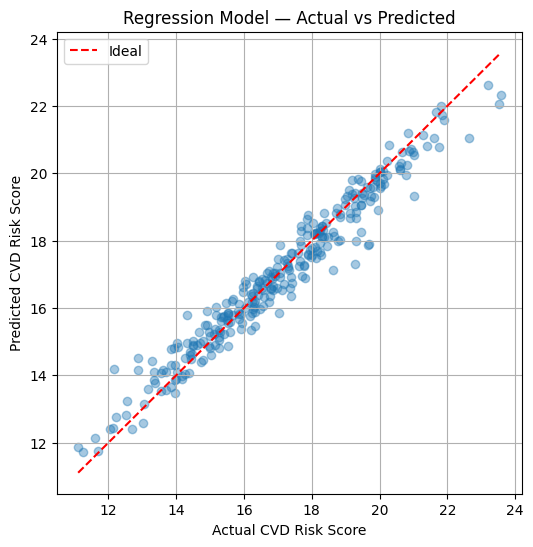

In [263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4)
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")
plt.xlabel("Actual CVD Risk Score")
plt.ylabel("Predicted CVD Risk Score")
plt.title("Regression Model — Actual vs Predicted")
plt.legend()
plt.grid()
plt.show()

# Best Model

In [264]:
model_variants = {
    "Logistic Regression": [
        ("Logistic Regression", accuracy),
        ("Logistic Regression (PCA)", accuracy_lr_pca)
    ],
    "Random Forest": [
        ("Random Forest", accuracy_rf_scr),
        ("Random Forest (PCA)", accuracy_rf_pca)
    ],
    "AdaBoost": [
        ("AdaBoost", accuracy_ab),
        ("AdaBoost (PCA)", accuracy_ab_pca)
    ],
    "Neural Network": [
        ("Neural Network", test_accuracy),
        ("Neural Network (PCA)", test_accuracy_pca)
    ],
    "KNN": [
        ("KNN (PCA)", accuracy_knn)
    ],
    "Gradient Boosting": [
        ("Gradient Boosting (PCA)", accuracy_gb)
    ]
}

model_accuracies = {}

for base_name, variants in model_variants.items():
    best_label, best_acc = max(variants, key=lambda v: v[1])
    model_accuracies[best_label] = best_acc

print("Test Accuracy Comparison (best variant per model):\n")

for model_name, model_accuracy in model_accuracies.items():
    print(
        f"{model_name}: {model_accuracy * 100:.2f}%"
    )

best_model = max(
    model_accuracies,
    key=model_accuracies.get
)

print("\nBest Model:", best_model)

print(
    "Best Test Accuracy:",
    f"{model_accuracies[best_model] * 100:.2f}%"
)

print("\nRegression (CVD Risk Score) R^2:", r2)

Test Accuracy Comparison (best variant per model):

Logistic Regression: 65.36%
Random Forest (PCA): 62.42%
AdaBoost: 64.38%
Neural Network: 67.97%
KNN (PCA): 58.17%
Gradient Boosting (PCA): 61.11%

Best Model: Neural Network
Best Test Accuracy: 67.97%

Regression (CVD Risk Score) R^2: 0.9509775671815479


# Evaluation

In [265]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

CLASS_NAMES = np.array([
    "HIGH",
    "INTERMEDIARY",
    "LOW"
])


# Neural Network prediction after PCA
probability_nn_pca = neural_network_pca.predict(
    X_nn_test_pca,
    verbose=0
)

y_pred_nn_pca_encoded = np.argmax(
    probability_nn_pca,
    axis=1
)

y_pred_nn_pca = label_encoder_nn.inverse_transform(
    y_pred_nn_pca_encoded
)


# Models before PCA
before_pca_predictions = {
    "Logistic Regression": y_pred,
    "Random Forest": y_pred_rf_scr,
    "AdaBoost": y_pred_ab,
    "Neural Network": y_pred_nn
}


# Models after PCA
after_pca_predictions = {
    "Logistic Regression": y_pred_lr_pca,
    "Random Forest": y_pred_rf_pca,
    "AdaBoost": y_pred_ab_pca,
    "Neural Network": y_pred_nn_pca,
    "KNN": y_pred_knn,
    "Gradient Boosting": y_pred_gb
}

# Confusion Matrices

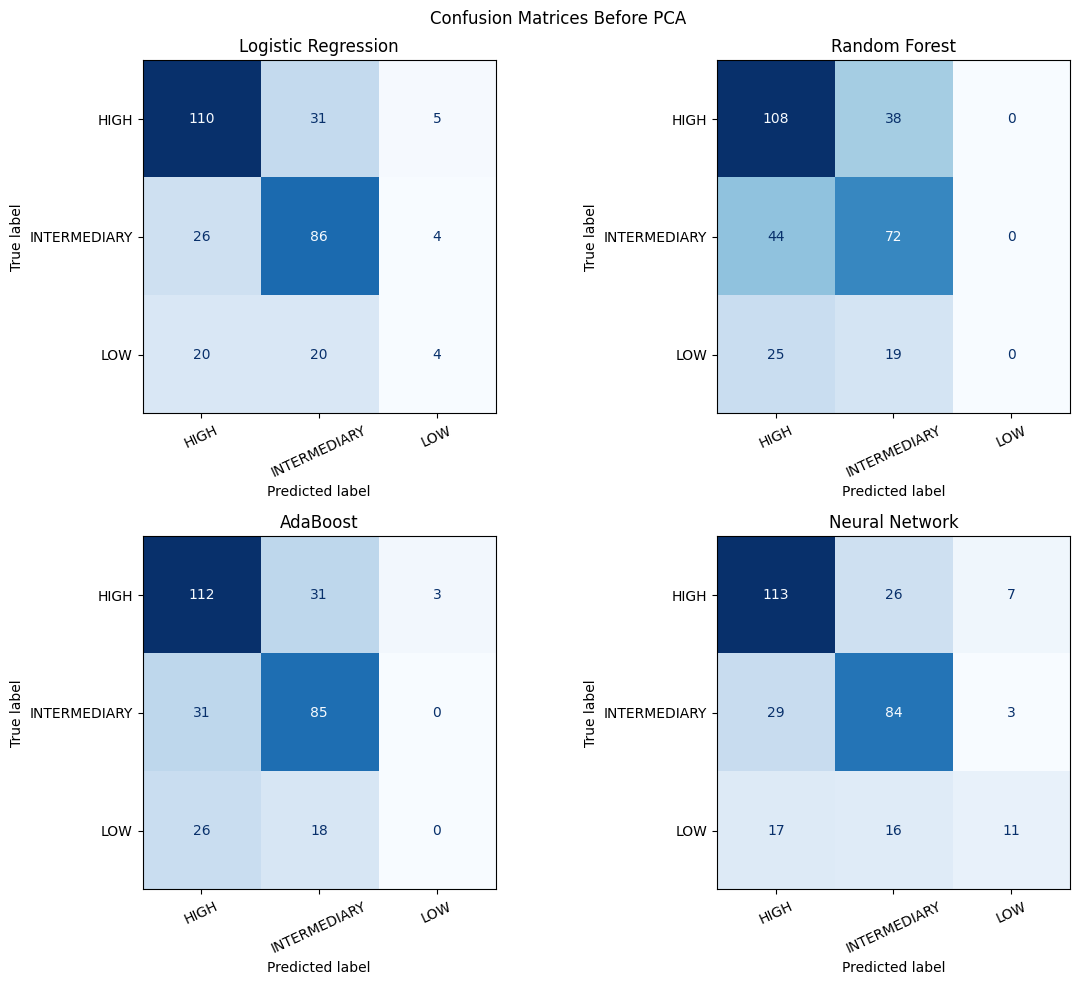

In [266]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, (model_name, prediction) in zip(
    axes,
    before_pca_predictions.items()
):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        labels=CLASS_NAMES,
        display_labels=CLASS_NAMES,
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Confusion Matrices Before PCA")
plt.tight_layout()
plt.show()

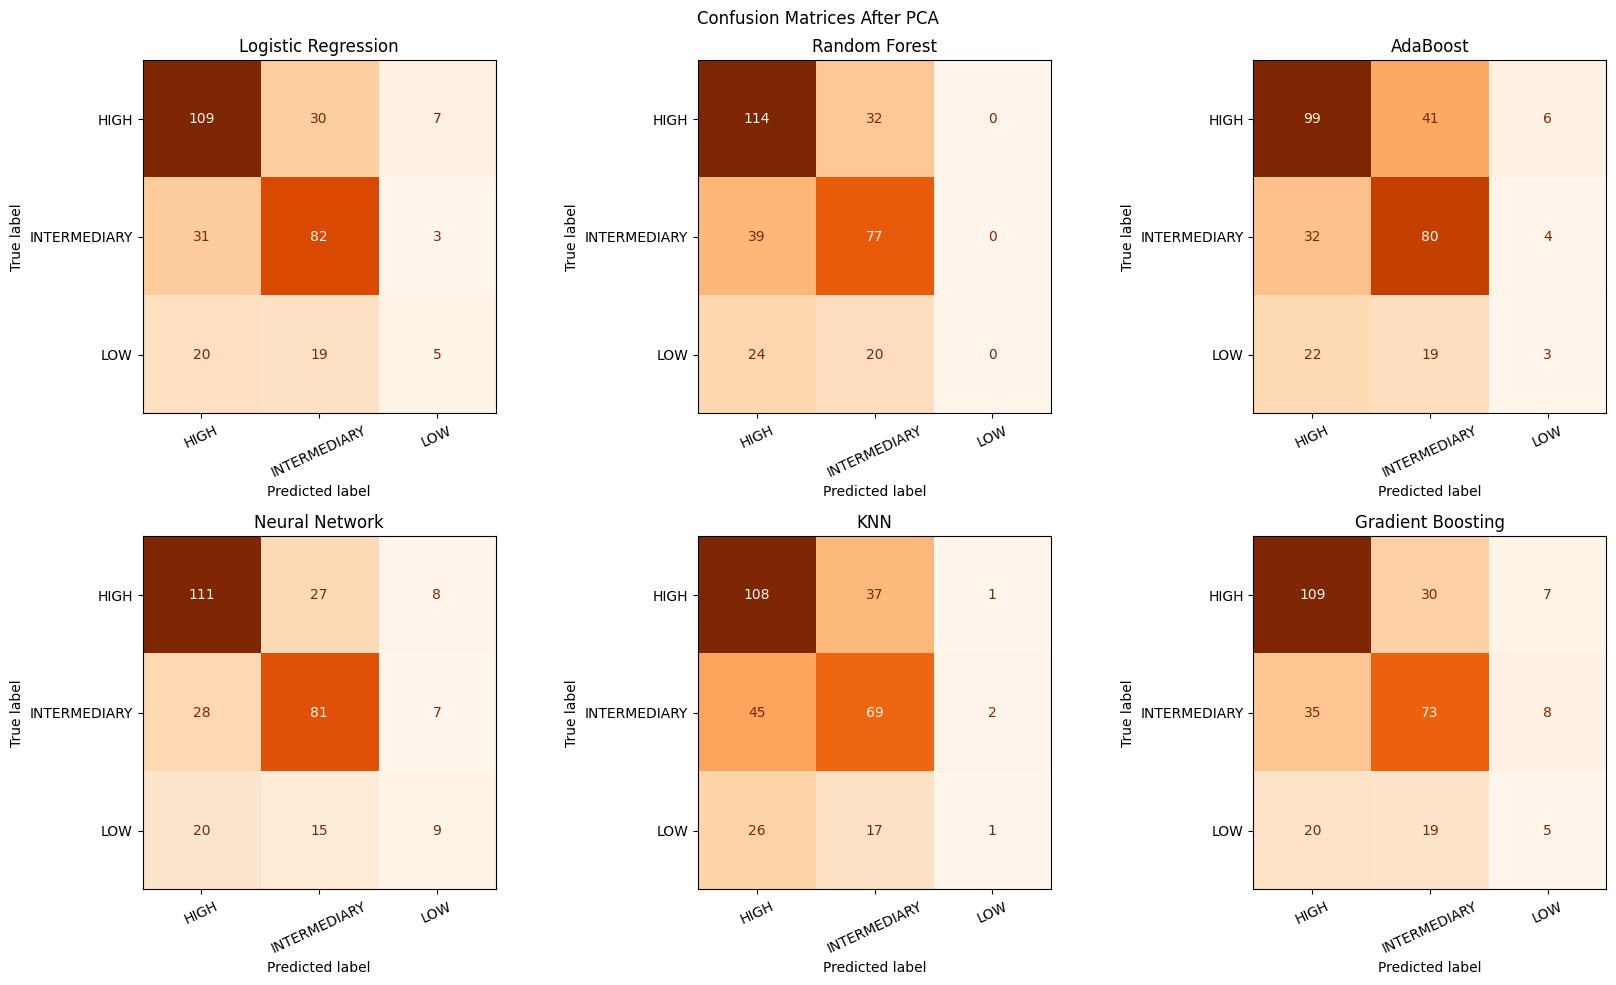

In [267]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 10)
)

axes = axes.flatten()

for ax, (model_name, prediction) in zip(
    axes,
    after_pca_predictions.items()
):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        labels=CLASS_NAMES,
        display_labels=CLASS_NAMES,
        cmap="Oranges",
        colorbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Confusion Matrices After PCA")
plt.tight_layout()
plt.show()

# False Negative

In [268]:
from sklearn.metrics import confusion_matrix

# Clinical focus: HIGH risk is the critical class. A false negative here
# means a genuinely high-risk patient got predicted as INTERMEDIARY or
# LOW — the most dangerous kind of error in a medical screening context.

print("False Negative Analysis — HIGH Risk Class\n")
print(f"{'Model':32s} {'FN Count':>10s} {'FN Rate':>10s} {'Recall (Sensitivity)':>22s}")
print("-" * 76)

fn_summary = {}

def compute_high_risk_fn(y_true, y_pred, class_names, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    high_idx = list(class_names).index("HIGH")

    high_total = cm[high_idx, :].sum()
    high_correct = cm[high_idx, high_idx]
    fn_count = high_total - high_correct
    fn_rate = fn_count / high_total
    recall = high_correct / high_total

    fn_summary[model_name] = fn_rate

    print(f"{model_name:32s} {fn_count:>10d} {fn_rate*100:>9.2f}% {recall*100:>21.2f}%")

print("-- Before PCA --")
for model_name, prediction in before_pca_predictions.items():
    compute_high_risk_fn(y_test, prediction, CLASS_NAMES, model_name)

print("\n-- After PCA --")
for model_name, prediction in after_pca_predictions.items():
    compute_high_risk_fn(y_test, prediction, CLASS_NAMES, model_name)

safest_model = min(fn_summary, key=fn_summary.get)
print(f"\nLowest false negative rate (HIGH risk cases): {safest_model} "
      f"({fn_summary[safest_model]*100:.2f}%)")

False Negative Analysis — HIGH Risk Class

Model                              FN Count    FN Rate   Recall (Sensitivity)
----------------------------------------------------------------------------
-- Before PCA --
Logistic Regression                      36     24.66%                 75.34%
Random Forest                            38     26.03%                 73.97%
AdaBoost                                 34     23.29%                 76.71%
Neural Network                           33     22.60%                 77.40%

-- After PCA --
Logistic Regression                      37     25.34%                 74.66%
Random Forest                            32     21.92%                 78.08%
AdaBoost                                 47     32.19%                 67.81%
Neural Network                           35     23.97%                 76.03%
KNN                                      38     26.03%                 73.97%
Gradient Boosting                        37     25.34%            

# ROC AUC Curve

In [269]:
from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression before PCA
lr_before = clone(logistic_model)
lr_before.fit(X_train, y_train)

# Classes converted into 0 and 1 format for ROC
y_test_binary = label_binarize(
    y_test,
    classes=CLASS_NAMES
)

roc_models = {
    "Logistic Regression — Before PCA": lr_before.predict_proba(X_test),
    "Random Forest — Before PCA":       random_forest.predict_proba(X_test_np),
    "AdaBoost — Before PCA":            adaboost.predict_proba(X_test_np),
    "Neural Network — Before PCA":      prediction_probabilities,

    "Logistic Regression — After PCA":  logistic_model_pca.predict_proba(X_test_pca),
    "Random Forest — After PCA":        random_forest_pca.predict_proba(X_test_pca),
    "AdaBoost — After PCA":             adaboost_pca.predict_proba(X_test_pca),
    "Neural Network — After PCA":       probability_nn_pca,

    "KNN — After PCA":                  knn_model.predict_proba(X_test_pca),
    "Gradient Boosting — After PCA":    gb_model.predict_proba(X_test_pca)
}

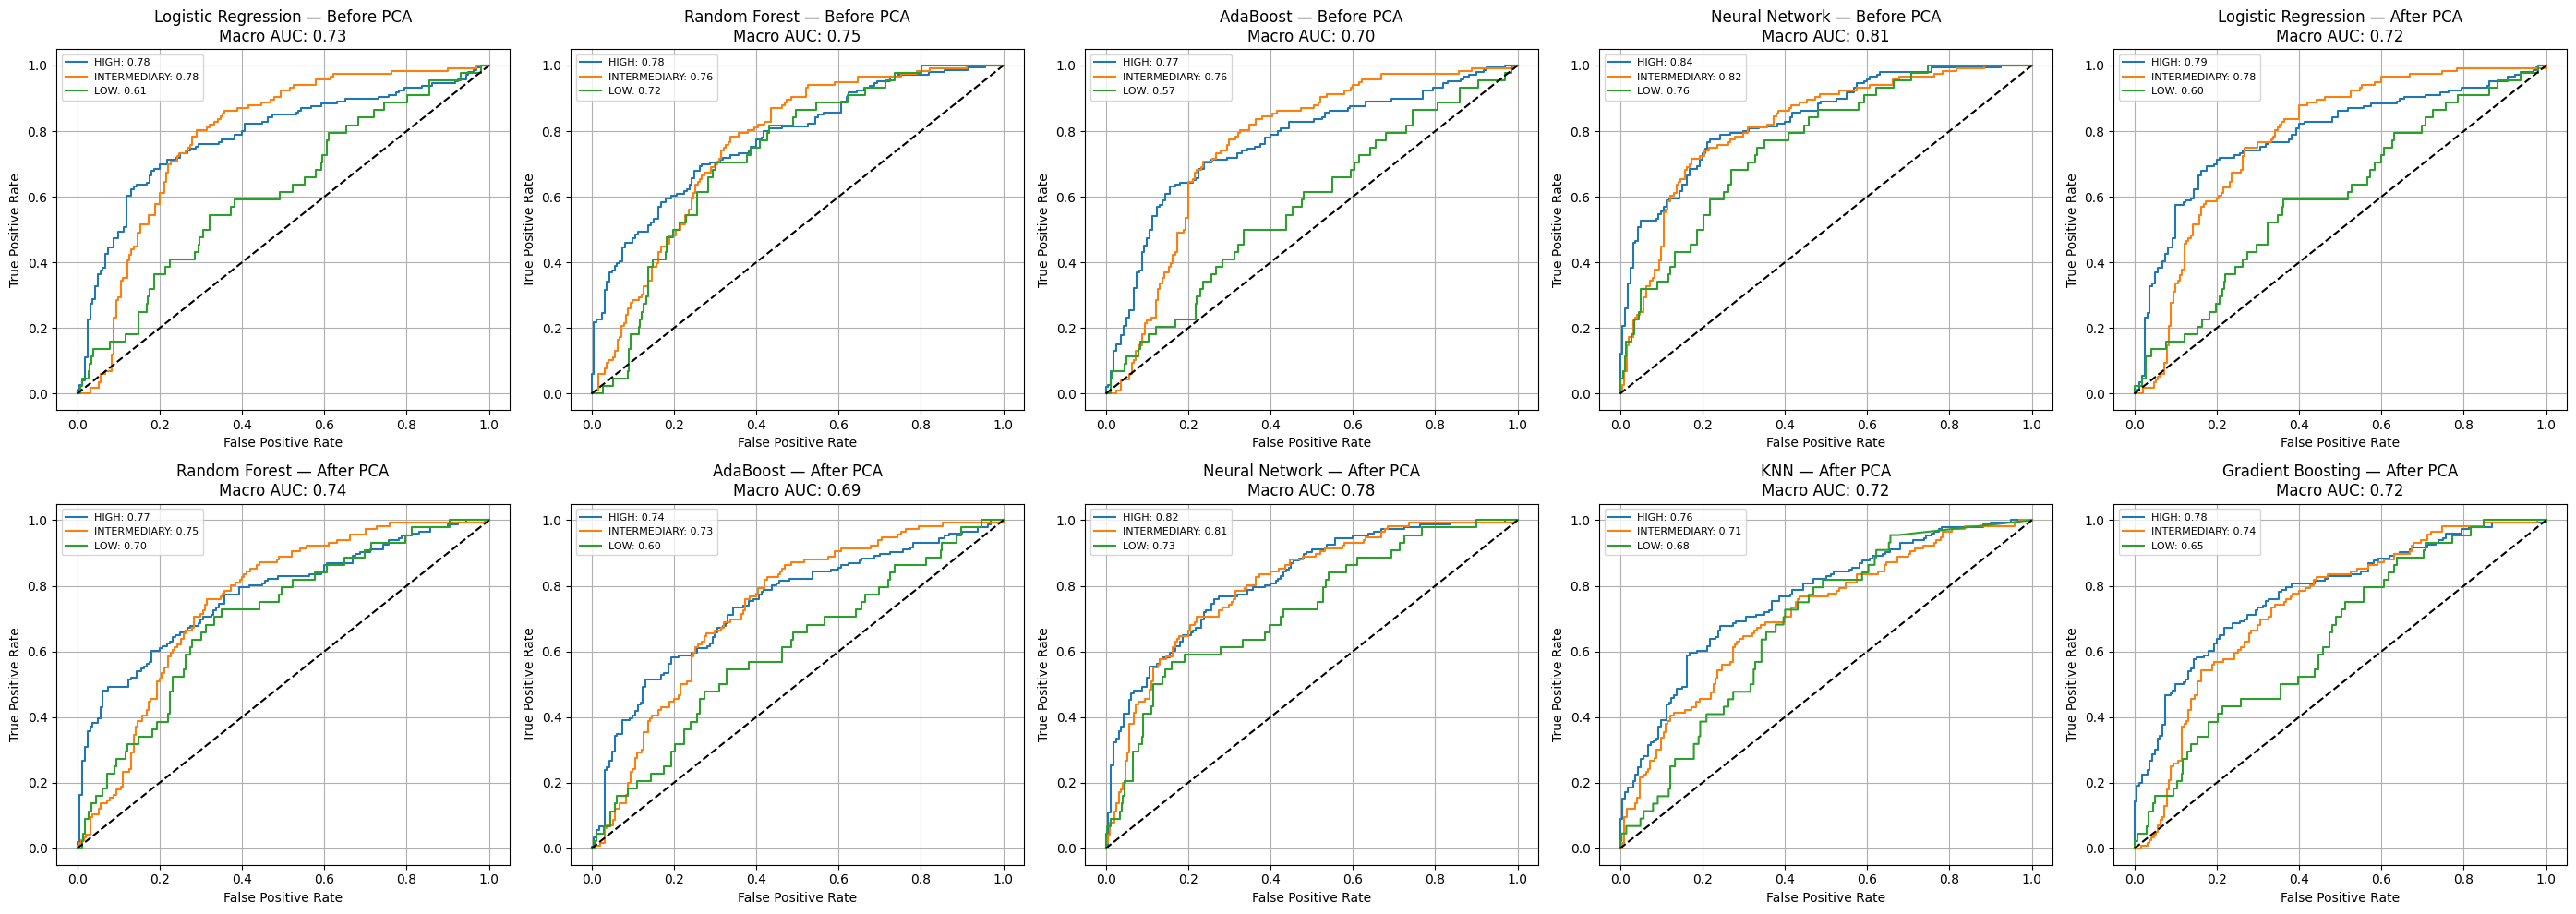

In [270]:
fig, axes = plt.subplots(2, 5, figsize=(28, 10))
axes = axes.flatten()

for ax, (model_name, probabilities) in zip(axes, roc_models.items()):

    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_binary[:, i], probabilities[:, i])
        auc_score = roc_auc_score(y_test_binary[:, i], probabilities[:, i])
        ax.plot(fpr, tpr, label=f"{class_name}: {auc_score:.2f}")

    macro_auc = roc_auc_score(y_test_binary, probabilities, average="macro")

    ax.plot([0, 1], [0, 1], "k--")
    ax.set_title(f"{model_name}\nMacro AUC: {macro_auc:.2f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid()

plt.tight_layout()
plt.show()

# Regression Residual Plot

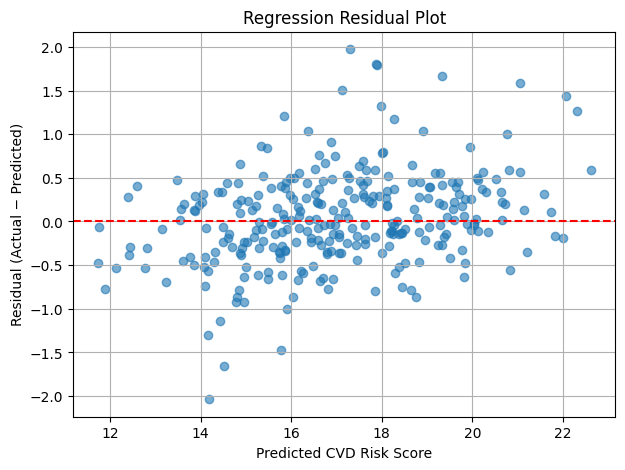

In [271]:
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted CVD Risk Score")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Regression Residual Plot")
plt.grid()
plt.show()